In [142]:
import pandas as pd
import numpy as np

In [143]:
df = pd.read_csv("data/match_dataset.csv")
df.head()

,team_id,team_name,game_id,game_date,matchup,wl,team_score,ennemy_score,score_differential,overtime,overtime_periods
0,1610612737,Atlanta Hawks,22401186,"APR 13, 2025",ATL vs. ORL,W,117,105,12,False,0
1,1610612737,Atlanta Hawks,22401173,"APR 11, 2025",ATL @ PHI,W,124,110,14,False,0
2,1610612737,Atlanta Hawks,22401169,"APR 10, 2025",ATL @ BKN,W,133,109,24,False,0
3,1610612737,Atlanta Hawks,22401149,"APR 08, 2025",ATL @ ORL,L,112,119,-7,False,0
4,1610612737,Atlanta Hawks,22401136,"APR 06, 2025",ATL vs. UTA,W,147,134,13,False,0


### Q1 — Dépendance offensive inter-équipes
Quand une équipe marque beaucoup dans un match, l'adversaire marque-t-il aussi **plus que d'habitude** ?
On commence Par définir pour un match donné les scores $X$ et $Y$ des deux équipes.

Or Pour ce faire, le dataset contient tous les matchs en double, pour ne pas être confronté à un biais statistique, il nous faut prendre en compte qu'un des 2 matchs. Ensuite, pour chaque match, désormais unique, se pose la question d'à qui attribuer $X$ et $Y$ sans induire un biais. Par exemple, si on attribuait à $X$ l'équipe qui est favorite, on se doute bien que l'adversaire ne marquera pas forcément plus. 

On pourrait choisir $X=$équipe à domicile $Y=$équipe à l'extérieur. Il y a évidemment un biais, car l'équipe à domicile devrait mieux jouer, mais on peut regarder le gain de point comparé à d'habitude: d'où $X=$ Score_domicile-moyenne_score_domicile_de_l'equipe et $Y=$ Score_exterieur-moyenne_score_exterieur_de l'equipe.

Avec ces définitions de $X$ et $Y$, on peut commencer à calculer $cov(X,Y)$

In [144]:
df["team_tag"]=df["matchup"].str[:3]
df["ennemy_tag"]=df["matchup"].str[-3:]
df["is_home"]=df["matchup"].str.contains("vs.")
df1=df[["game_id","game_date","team_tag","ennemy_tag","team_score","ennemy_score","is_home","overtime","overtime_periods"]]
df1.head()

,game_id,game_date,team_tag,ennemy_tag,team_score,ennemy_score,is_home,overtime,overtime_periods
0,22401186,"APR 13, 2025",ATL,ORL,117,105,True,False,0
1,22401173,"APR 11, 2025",ATL,PHI,124,110,False,False,0
2,22401169,"APR 10, 2025",ATL,BKN,133,109,False,False,0
3,22401149,"APR 08, 2025",ATL,ORL,112,119,False,False,0
4,22401136,"APR 06, 2025",ATL,UTA,147,134,True,False,0


In [145]:
df1['team_score_avg_by_home'] = (
    df1
    .groupby(['team_tag', 'is_home'])['team_score']
    .transform('mean')
)
df1["ennemy_score_avg_by_home"] =(
    df1
    .groupby(['ennemy_tag', 'is_home'])['ennemy_score']
    .transform('mean')
)
df1.head()

,game_id,game_date,team_tag,ennemy_tag,team_score,ennemy_score,is_home,overtime,overtime_periods,team_score_avg_by_home,ennemy_score_avg_by_home
0,22401186,"APR 13, 2025",ATL,ORL,117,105,True,False,0,118.225000,105.219512
1,22401173,"APR 11, 2025",ATL,PHI,124,110,False,False,0,118.142857,109.268293
2,22401169,"APR 10, 2025",ATL,BKN,133,109,False,False,0,118.142857,103.780488
3,22401149,"APR 08, 2025",ATL,ORL,112,119,False,False,0,118.142857,105.634146
4,22401136,"APR 06, 2025",ATL,UTA,147,134,True,False,0,118.225000,112.658537


In [146]:
df1["team_score_gap"]=df1["team_score"]-df1["team_score_avg_by_home"]
df1["ennemy_score_gap"]=df1["ennemy_score"]-df1["ennemy_score_avg_by_home"]
df1['score_gap_home_side'] = np.where(
    df1['is_home'],
    df1['team_score_gap'],    # si team est à domicile
    df1['ennemy_score_gap']   # si team est à l’extérieur
)
df1['score_gap_away_side'] = np.where(
    df1['is_home'],
    df1['ennemy_score_gap'],
    df1['team_score_gap']  
)
df1.head()

,game_id,game_date,team_tag,ennemy_tag,team_score,ennemy_score,is_home,overtime,overtime_periods,team_score_avg_by_home,ennemy_score_avg_by_home,team_score_gap,ennemy_score_gap,score_gap_home_side,score_gap_away_side
0,22401186,"APR 13, 2025",ATL,ORL,117,105,True,False,0,118.225000,105.219512,-1.225000,-0.219512,-1.225000,-0.219512
1,22401173,"APR 11, 2025",ATL,PHI,124,110,False,False,0,118.142857,109.268293,5.857143,0.731707,0.731707,5.857143
2,22401169,"APR 10, 2025",ATL,BKN,133,109,False,False,0,118.142857,103.780488,14.857143,5.219512,5.219512,14.857143
3,22401149,"APR 08, 2025",ATL,ORL,112,119,False,False,0,118.142857,105.634146,-6.142857,13.365854,13.365854,-6.142857
4,22401136,"APR 06, 2025",ATL,UTA,147,134,True,False,0,118.225000,112.658537,28.775000,21.341463,28.775000,21.341463


In [147]:
score_gap = df1.drop_duplicates(subset=['game_id']).reset_index(drop=True)
score_gap=score_gap[["score_gap_home_side","score_gap_away_side"]]
score_gap.head()

,score_gap_home_side,score_gap_away_side
0,-1.225000,-0.219512
1,0.731707,5.857143
2,5.219512,14.857143
3,13.365854,-6.142857
4,28.775000,21.341463


Rappel :

score_gap_team_home = performance de l'équipe domicile par rapport à son niveau habituel
score_gap_team_away = performance de l'équipe extérieur par rapport à son niveau habituel

On a déjà neutralisé :

niveau des équipes
effet domicile / extérieur

In [148]:
home_score_gap=df1["score_gap_home_side"].to_numpy()
away_score_gap=df1["score_gap_away_side"].to_numpy()
print(np.corrcoef(home_score_gap,away_score_gap)[0,1])

0.22905421325873795


En première calcul, la corrélation de 0.229 indique bien que si une équipe a une performance plus élevée ce sera de même pour l'équipe adverse !!!!

L'intérêt et donc de confirmer ce fait par les copules qui devrait donc mieux modéliser la dépendance.

In [149]:
from scipy.stats import rankdata
n = len(score_gap)

score_gap["u"] = rankdata(score_gap["score_gap_home_side"]) / (n + 1)
score_gap["v"] = rankdata(score_gap["score_gap_away_side"]) / (n + 1)

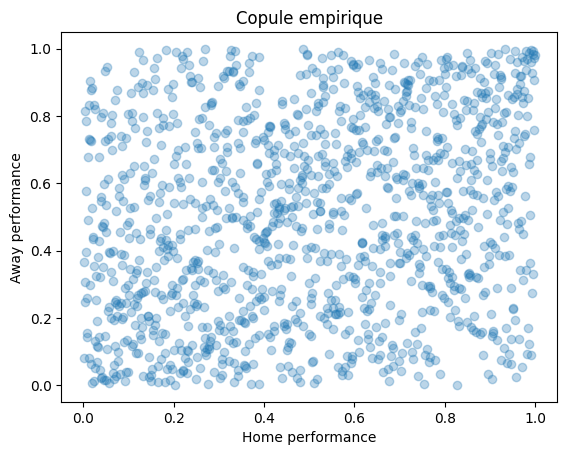

In [150]:
import matplotlib.pyplot as plt

plt.scatter(score_gap["u"], score_gap["v"], alpha=0.3)
plt.xlabel("Home performance")
plt.ylabel("Away performance")
plt.title("Copule empirique")
plt.show()

In [151]:
from scipy.stats import kendalltau

tau, p = kendalltau(score_gap["u"], score_gap["v"])
print(tau, p)

0.15033282729940523 3.062003794914066e-15


In [152]:
threshold = 0.9

upper_tail = np.mean(
    (score_gap["u"] > threshold) &
    (score_gap["v"] > threshold)
) / (1 - threshold)

print(upper_tail)

0.2276422764227643


In [153]:
lower_tail = np.mean(
    (score_gap["u"] < 0.1) &
    (score_gap["v"] < 0.1)
) / 0.1
print(lower_tail)

0.18699186991869918


L'analyse de dépendance entre les performances offensives des deux équipes montre une dépendance positive mais modérée.
Le coefficient de Kendall τ est de 0.15, indiquant que lorsque l'une des équipes marque plus que d'habitude, l'adversaire a également tendance à marquer légèrement plus.

L'analyse des dépendances dans les extrêmes montre une dépendance légèrement plus forte dans les matchs offensifs (upper tail = 0.22) que dans les matchs défensifs (lower tail = 0.19).

Cela suggère que les matchs rapides ou ouverts favorisent des performances offensives élevées pour les deux équipes, probablement en raison d'un rythme de jeu partagé.

Donc :

pas de structure forte
mais légère diagonale

La copule modélisant la situation devrait donc être soit t-student ou gaussienne, vu qu'il n'y a pas tant d'asymétrie et que les déviations sont modérées.

In [154]:
import pyvinecopulib as pv

# DataFrame score_gap avec colonnes 'u' et 'v'
data = np.column_stack([score_gap["u"].to_numpy(dtype=np.float64),
                        score_gap["v"].to_numpy(dtype=np.float64)])

# Conversion Fortran order
data = np.asfortranarray(data)

families = [
    pv.BicopFamily.gaussian,
    pv.BicopFamily.student,
    pv.BicopFamily.clayton,
    pv.BicopFamily.gumbel,
    pv.BicopFamily.frank
]

results = {}

for fam in families:
    cop = pv.Bicop(family=fam)
    cop.fit(data)
    results[fam] = cop.loglik(data)

results

{BicopFamily.gaussian: 33.29813295586743,
 BicopFamily.student: 35.75272982128206,
 BicopFamily.clayton: 21.124948430564267,
 BicopFamily.gumbel: 37.26577314349732,
 BicopFamily.frank: 31.40404136451164}

Le log likelihood donne Gumbel comme copule idéal

BicopFamily.gaussian: AIC = -64.60
BicopFamily.student: AIC = -67.51
BicopFamily.clayton: AIC = -40.25
BicopFamily.gumbel: AIC = -72.53
BicopFamily.frank: AIC = -60.81

Meilleure copule : gumbel avec AIC = -72.53
Kendall's tau : 0.140
Spearman rho : 0.221


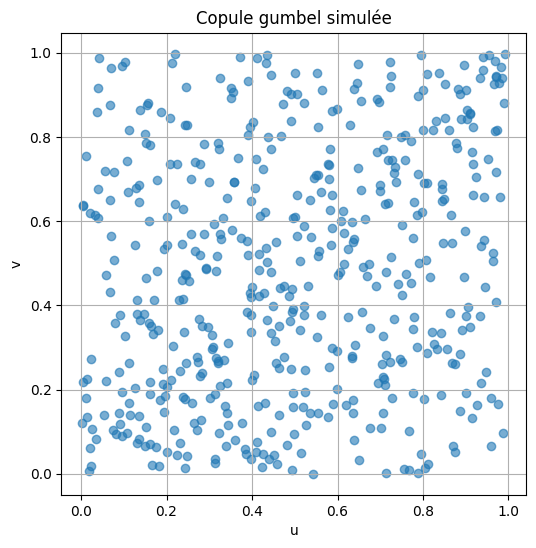

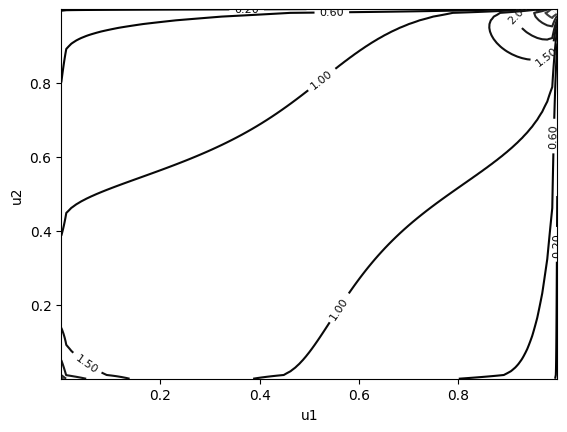

In [155]:
best_aic = np.inf
best_cop = None
best_family = None

for fam in families:
    cop = pv.Bicop(family=fam)
    cop.fit(data)
    aic = cop.aic(data)
    print(f"{fam}: AIC = {aic:.2f}")
    if aic < best_aic:
        best_aic = aic
        best_cop = cop
        best_family = fam
print(f"\nMeilleure copule : {best_family.name} avec AIC = {best_aic:.2f}")
print(f"Kendall's tau : {best_cop.tau:.3f}")

from scipy.stats import spearmanr
# --- Calculer Spearman rho ---
rho, _ = spearmanr(score_gap["u"], score_gap["v"])
print(f"Spearman rho : {rho:.3f}")

# --- Simuler N observations ---
N = 500
sim_samples = best_cop.simulate(N)

# --- Visualiser la copule ---
plt.figure(figsize=(6,6))
plt.scatter(sim_samples[:,0], sim_samples[:,1], alpha=0.6)
plt.title(f"Copule {best_family.name} simulée")
plt.xlabel("u")
plt.ylabel("v")
plt.grid(True)
plt.show()

# --- Tracer un contour (densité) ---
best_cop.plot(type="contour")
plt.show()

Avec le rho de spearman à 0.22 on retrouve une faible corrélation positive comme avec le tau de Kendall. Remarquons que le choix de Gumbel comme meilleure copule peut intérroger car il n'y a pas d'asymétrie de dépendance entre les variables faibles et grandes.

### Q2 — Back-to-back
Les équipes NBA jouent ~82 matchs en 6 mois, avec environ **15 back-to-backs** par saison (deux matchs consécutifs, J et J+1).
Quelle est la structure de dépendance sur les résultats ?

In [ ]:
btb=df1[["game_date","team_tag","team_score"]]
btb.rename(columns={'game_date': 'date','team_tag': 'team', 'team_score': 'score'}, inplace=True)
btb.head()
btb.shape

(2460, 3)

In [157]:
btb.head()

,date,team,score_gap
0,"APR 13, 2025",ATL,-1.225000
1,"APR 11, 2025",ATL,5.857143
2,"APR 10, 2025",ATL,14.857143
3,"APR 08, 2025",ATL,-6.142857
4,"APR 06, 2025",ATL,28.775000


In [179]:
# Si tes dates ressemblent à "APR 13, 2025"
btb['date'] = pd.to_datetime(btb['date'], format='%b %d, %Y')


btb = btb.sort_values(['team', 'date'])
# shift pour récupérer le match suivant pour la même équipe
btb['score_next'] = btb.groupby('team')['score'].shift(-1)

# flag back-to-back : match à J+1 moins de 2 jours après
btb['days_diff'] = btb.groupby('team')['date'].diff(-1).abs().dt.days
btb['back_to_back'] = btb['days_diff'] <= 1
# garder seulement back-to-back
btb = btb[btb['back_to_back']]
btb.head()


,date,team,score,score_next,days_diff,back_to_back
79,2024-10-27,ATL,104,119.0,1.0,True
75,2024-11-03,ATL,126,93.0,1.0,True
72,2024-11-08,ATL,121,113.0,1.0,True
68,2024-11-17,ATL,110,109.0,1.0,True
62,2024-11-29,ATL,117,107.0,1.0,True


In [168]:
btb.shape

(450, 6)

In [180]:
btb=btb[["score","score_next"]]

In [185]:
day_before=btb["score"].to_numpy()
day_after=btb["score_next"].to_numpy()
print(np.corrcoef(day_before,day_after)[0,1])
print(np.mean(day_after-day_before))

0.18907442515674344
-2.2644444444444445


On remarque qu'en moyenne une équipe perd 2 à 3 points en jouant dès le lendemain d'un match. Aussi, en comparant le score le jour J et le jour J+1, on voit une corrélation légèrement positive. Cela est contre-intuitif car on s'attendrait à ce que si le score au jour J devient grand, alors la fatigue entraînée fera chuter le score le lendemain. Force est de constater que les joueurs auront tendance à "conserver" leur niveau de jeu lors du match du lendemain.

On refait la même procédure pour calculer les perfs:

In [186]:
n = len(btb)

btb["u"] = rankdata(btb["score"]) / (n + 1)
btb["v"] = rankdata(btb["score_next"]) / (n + 1)

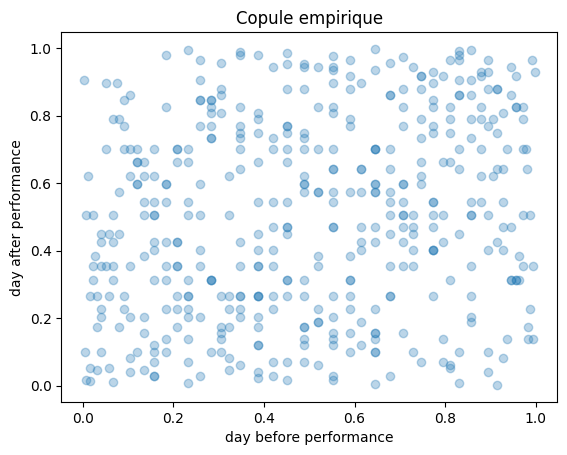

In [187]:
plt.scatter(btb["u"], btb["v"], alpha=0.3)
plt.xlabel("day before performance")
plt.ylabel("day after performance")
plt.title("Copule empirique")
plt.show()

In [189]:
tau, p = kendalltau(btb["u"], btb["v"])
print(tau, p)

0.14075906482965178 1.2779350072979302e-05


In [190]:
threshold = 0.9

upper_tail = np.mean(
    (btb["u"] > threshold) &
    (btb["v"] > threshold)
) / (1 - threshold)

print(upper_tail)

0.0888888888888889


In [191]:
lower_tail = np.mean(
    (btb["u"] < 0.1) &
    (btb["v"] < 0.1)
) / 0.1
print(lower_tail)

0.17777777777777776


In [192]:
data = np.column_stack([btb["u"].to_numpy(dtype=np.float64),
                        btb["v"].to_numpy(dtype=np.float64)])

# Conversion Fortran order
data = np.asfortranarray(data)
families = [
    pv.BicopFamily.gaussian,
    pv.BicopFamily.student,
    pv.BicopFamily.clayton,
    pv.BicopFamily.gumbel,
    pv.BicopFamily.frank
]

results = {}

for fam in families:
    cop = pv.Bicop(family=fam)
    cop.fit(data)
    results[fam] = cop.loglik(data)

results

{BicopFamily.gaussian: 8.954044298087663,
 BicopFamily.student: 8.962212233323655,
 BicopFamily.clayton: 7.397576632935612,
 BicopFamily.gumbel: 6.210416541615711,
 BicopFamily.frank: 9.844532658878023}

BicopFamily.gaussian: AIC = -5.34
BicopFamily.student: AIC = -2.93
BicopFamily.clayton: AIC = -7.34
BicopFamily.gumbel: AIC = -0.64
BicopFamily.frank: AIC = -5.23

Meilleure copule : clayton avec AIC = -7.34
Kendall's tau : 0.166
Spearman rho : 0.209


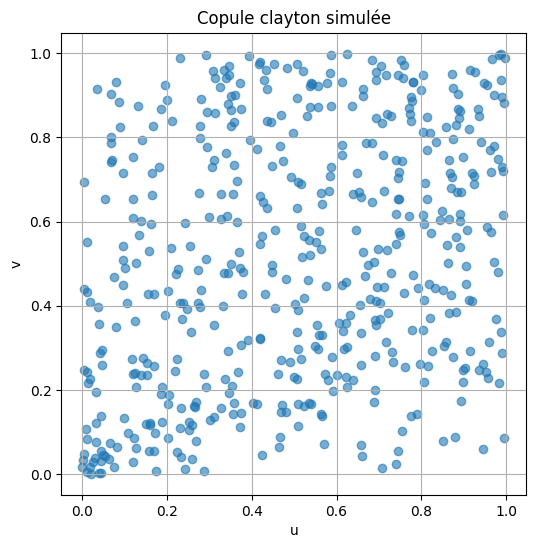

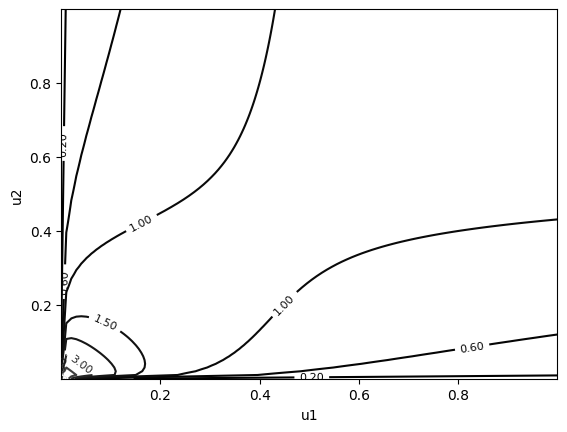

In [231]:
best_aic = np.inf
best_cop = None
best_family = None

for fam in families:
    cop = pv.Bicop(family=fam)
    cop.fit(data)
    aic = cop.aic(data)
    print(f"{fam}: AIC = {aic:.2f}")
    if aic < best_aic:
        best_aic = aic
        best_cop = cop
        best_family = fam
print(f"\nMeilleure copule : {best_family.name} avec AIC = {best_aic:.2f}")
print(f"Kendall's tau : {best_cop.tau:.3f}")

from scipy.stats import spearmanr
# --- Calculer Spearman rho ---
rho, _ = spearmanr(btb["u"], btb["v"])
print(f"Spearman rho : {rho:.3f}")

# --- Simuler N observations ---
N = 500
sim_samples = best_cop.simulate(N)

# --- Visualiser la copule ---
plt.figure(figsize=(6,6))
plt.scatter(sim_samples[:,0], sim_samples[:,1], alpha=0.6)
plt.title(f"Copule {best_family.name} simulée")
plt.xlabel("u")
plt.ylabel("v")
plt.grid(True)
plt.show()

# --- Tracer un contour (densité) ---
best_cop.plot(type="contour")
plt.show()

Copule Frank pour les évènements pas trop extrêmes, là encore il n'y a pas de copule asymétrique qui a été choisie alors que dans ce cas si la mesure des lower et upper tail indique que si.

### Q3 — Impact des prolongations (overtime)
Les matchs en OT entraînent-ils de **moins bonnes performances** dans les matchs suivants ?

In [204]:
ot_match=df1[["game_date","team_tag","team_score","overtime"]]
ot_match.rename(columns={'game_date': 'date','team_tag': 'team', 'team_score': 'score'}, inplace=True)


In [205]:
# Si tes dates ressemblent à "APR 13, 2025"
ot_match['date'] = pd.to_datetime(ot_match['date'], format='%b %d, %Y')


ot_match = ot_match.sort_values(['team', 'date'])
ot_match =ot_match[["team","score","overtime"]]
# match suivant
ot_match['score_next'] = ot_match.groupby('team')['score'].shift(-1)

# ne garder que les matchs OT
ot_match = ot_match[ot_match['overtime']]


In [216]:
ot_match = ot_match[["score","score_next"]]
ot_match = ot_match.dropna(subset=['score_next'])
ot_match.head()


,score,score_next
58,134,111.0
54,126,112.0
41,119,110.0
27,148,108.0
1226,139,119.0


In [217]:
ot_match.shape

(114, 2)

In [219]:
day_before=ot_match["score"].to_numpy()
day_after=ot_match["score_next"].to_numpy()

print(np.corrcoef(day_before,day_after)[0,1])
print(np.mean(day_after-day_before))

0.22387647438221156
-12.192982456140351


Même résultats que pour Q2, les bonnes performances se prolonge jusqu'aux matchs suivants.

In [220]:
n = len(ot_match)

ot_match["u"] = rankdata(ot_match["score"]) / (n + 1)
ot_match["v"] = rankdata(ot_match["score_next"]) / (n + 1)

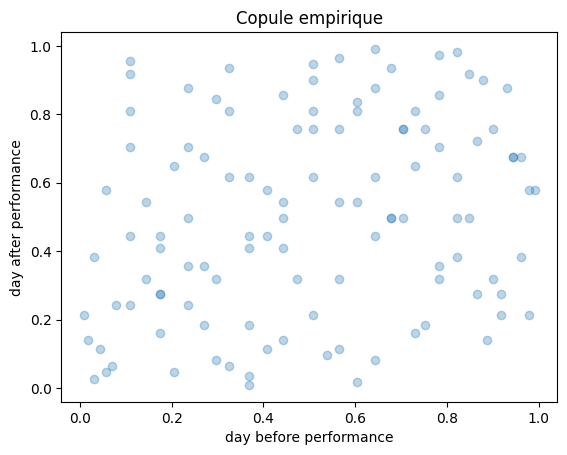

In [221]:
plt.scatter(ot_match["u"], ot_match["v"], alpha=0.3)
plt.xlabel("day before performance")
plt.ylabel("day after performance")
plt.title("Copule empirique")
plt.show()

In [222]:
tau, p = kendalltau(ot_match["u"], ot_match["v"])
print(tau, p)

0.16986083552714992 0.008811397748495705


In [226]:
threshold = 0.85

upper_tail = np.mean(
    (ot_match["u"] > threshold) &
    (ot_match["v"] > threshold)
) / (1 - threshold)

print(upper_tail)

0.11695906432748536


(Pour threshoold=0.9 on avait 0 ...)

In [228]:
lower_tail = np.mean(
    (ot_match["u"] < 0.1) &
    (ot_match["v"] < 0.1)
) / 0.1
print(lower_tail)

0.2631578947368421


Intéressant, cela indiquerait plutôt qu'une mauvaise perf en match overtime conduirait aussi lourdement vers une grosse défaite au prochain match

In [232]:
data = np.column_stack([ot_match["u"].to_numpy(dtype=np.float64),
                        ot_match["v"].to_numpy(dtype=np.float64)])

# Conversion Fortran order
data = np.asfortranarray(data)
families = [
    pv.BicopFamily.gaussian,
    pv.BicopFamily.student,
    pv.BicopFamily.clayton,
    pv.BicopFamily.gumbel,
    pv.BicopFamily.frank
]

results = {}

for fam in families:
    cop = pv.Bicop(family=fam)
    cop.fit(data)
    results[fam] = cop.loglik(data)

results

{BicopFamily.gaussian: 3.6685315916821333,
 BicopFamily.student: 3.4630575969824164,
 BicopFamily.clayton: 4.668899286374445,
 BicopFamily.gumbel: 1.3196811972463425,
 BicopFamily.frank: 3.6134427035865055}

Légère préférence pour la Clayton qui capture mieux la dépendance vers la queue inférieure, là c'est logique !!

BicopFamily.gaussian: AIC = -5.34
BicopFamily.student: AIC = -2.93
BicopFamily.clayton: AIC = -7.34
BicopFamily.gumbel: AIC = -0.64
BicopFamily.frank: AIC = -5.23

Meilleure copule : clayton avec AIC = -7.34
Kendall's tau : 0.166
Spearman rho : 0.253


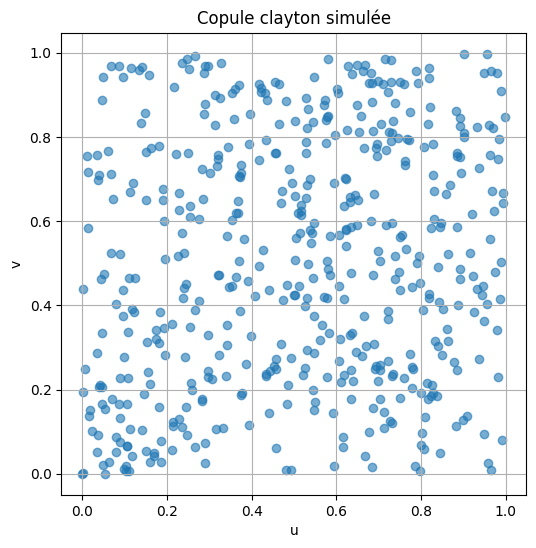

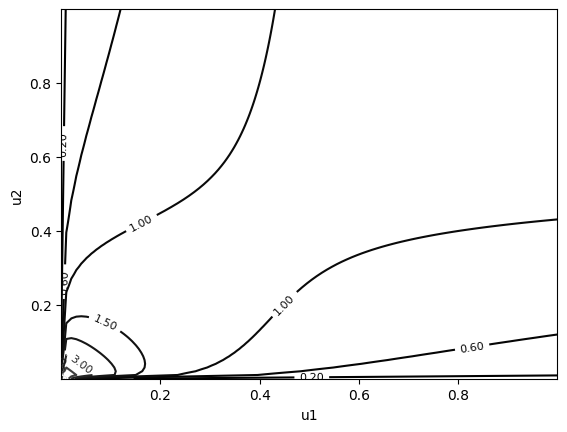

In [233]:
best_aic = np.inf
best_cop = None
best_family = None

for fam in families:
    cop = pv.Bicop(family=fam)
    cop.fit(data)
    aic = cop.aic(data)
    print(f"{fam}: AIC = {aic:.2f}")
    if aic < best_aic:
        best_aic = aic
        best_cop = cop
        best_family = fam
print(f"\nMeilleure copule : {best_family.name} avec AIC = {best_aic:.2f}")
print(f"Kendall's tau : {best_cop.tau:.3f}")

from scipy.stats import spearmanr
# --- Calculer Spearman rho ---
rho, _ = spearmanr(ot_match["u"], ot_match["v"])
print(f"Spearman rho : {rho:.3f}")

# --- Simuler N observations ---
N = 500
sim_samples = best_cop.simulate(N)

# --- Visualiser la copule ---
plt.figure(figsize=(6,6))
plt.scatter(sim_samples[:,0], sim_samples[:,1], alpha=0.6)
plt.title(f"Copule {best_family.name} simulée")
plt.xlabel("u")
plt.ylabel("v")
plt.grid(True)
plt.show()

# --- Tracer un contour (densité) ---
best_cop.plot(type="contour")
plt.show()